In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [ ]:
train_data = pd.read_csv("train_data.csv", delimiter = ";")
test_data = pd.read_csv("test_data.csv", delimiter = ";")

train_data.head()

df = pd.DataFrame(train_data)

#x_split = df["rel_1","rel_2","rel_3","rel_4","rel_5","rel_6","rel_7","rel_8","rel_9","cnorm_1","cnorm_2","age","gender","ethnicity","ses","denomination","education"]
y_split = df["wb_overall_mean"]




#print(train_data.to_string())
#split datasets
train_data = train_data[["rel_1","rel_2","rel_3","rel_4","rel_5",
                         "rel_6","rel_7","rel_8","rel_9","cnorm_1",
                         "cnorm_2","age","gender","ethnicity","ses","denomination","education"]]
#y_train = train_data[["wb_overall_mean"]]

train_data_dummies = pd.get_dummies(train_data)
#x_test_dummies = pd.get_dummies(x_test)



x_train, x_test, y_train, y_test = train_test_split(train_data_dummies, y_split, test_size = 0.2, random_state = 42)

In [ ]:
train_data_dummies

Progress log: Read up on the data (conceptual analysis), read in the data into a jupyter notebook and fit a normal linear regression line. The regression takes the responses from the rel_ responses and compares it to the overall well-being score. Maybe what would be good to do is compare the coefficients to the other mean scores instead of just the overall. Maybe it would be good to run a correlation test. Regression coefficients:  [0.204401,-0.06756281,0.04235165,0.05646504,0.03557858,0.01394905,-0.06650978,-0.0040522,0.05508881]

In [4]:
rf_model = RandomForestRegressor()

rf_model.fit(x_train, y_train)


y_pred = rf_model.predict(x_train)


#print(rf_model)



In [5]:
print(rf_model.predict(x_train))



[3.54509804 3.45879085 3.52199346 ... 3.54101307 3.75150327 3.94522876]


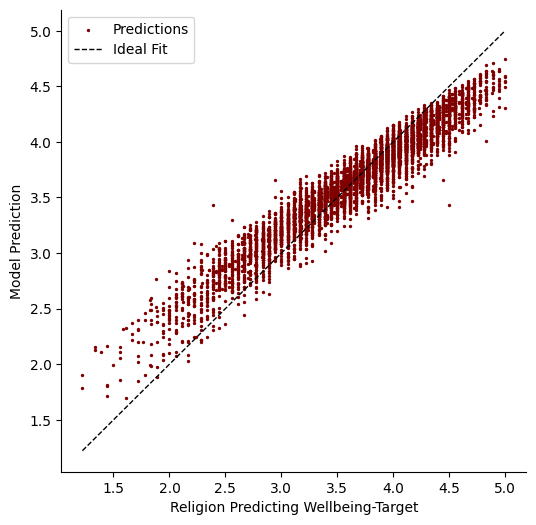

In [6]:
#Create the figure and axis
f, ax = plt.subplots(1, 1, figsize=(6, 6))

#Scatter plot of true vs predicted values
ax.scatter(y_train, y_pred, color="maroon", s=2, label="Predictions")

#Get limits for the diagonal reference line
min_val = min(np.min(y_train), np.min(y_pred))
max_val = max(np.max(y_train), np.max(y_pred))

#Plot the black dashed diagonal line
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label="Ideal Fit")

#Set labels
ax.set_xlabel("Religion Predicting Wellbeing-Target")
ax.set_ylabel("Model Prediction")

#Remove top and right spines
sns.despine(ax=ax)

#Add legend
ax.legend()

#Show plot
plt.show()


In [7]:
#test_pred = rf_model.fit(x_test_dummies,y_test)

#y_test_pred = rf_model.predict(x_test_dummies)

y_pred_test = rf_model.predict(x_test)

print(y_pred_test)


[3.8924183  3.29761438 3.82336601 ... 3.49062092 3.66133987 3.97673203]


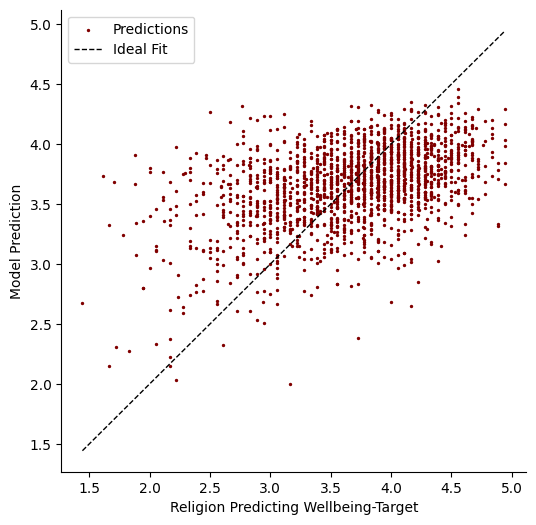

In [8]:
#Create the figure and axis
f, ax = plt.subplots(1, 1, figsize=(6, 6))

#Scatter plot of true vs predicted values
ax.scatter(y_test, y_pred_test, color="maroon", s=2, label="Predictions")

#Get limits for the diagonal reference line
min_val = min(np.min(y_test), np.min(y_pred_test))
max_val = max(np.max(y_test), np.max(y_pred_test))

#Plot the black dashed diagonal line
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label="Ideal Fit")

#Set labels
ax.set_xlabel("Religion Predicting Wellbeing-Target")
ax.set_ylabel("Model Prediction")

#Remove top and right spines
sns.despine(ax=ax)

#Add legend
ax.legend()

#Show plot
plt.show()

Provide evaluation here